Welcome to the reference implementation notebook for the **On Top of Pasketti: Children's Speech Recognition Challenge - Phonetic Track**! If you are just getting started, we recommend reading the [competition webpage](https://www.drivendata.org/competitions/309/childrens-phonetic-asr/) first. 

The goal of this tutorial is to: 
1. Demonstrate how to [load and explore the data](#Step-1:-Load-and-explore-the-data).
2. Provide a basic framework for [building a model](#Step-2:-Build-the-Model).
3. Walk through how to [package your work](#Step-3:-Make-your-submission) correctly for submission.

We will be fine-tuning [Wav2Vec2](https://huggingface.co/docs/transformers/en/model_doc/wav2vec2), a pretrained speech representation model for automatic speech recognition ("ASR"), using the Hugging Face Transformers library. Wav2Vec2 converts raw audio into contextual acoustic representations through a convolutional feature extractor followed by a Transformer encoder.

For this challenge, we adapt Wav2Vec2 to predict phonetic units (phones) represented by the International Phonetic Alphabet (IPA) rather than words or characters. While Wav2Vec2 is commonly fine-tuned for grapheme- or word-level ASR, its learned acoustic representations can also support phone-level prediction. By training the model with an IPA phone vocabulary and using [Connectionist Temporal Classification (CTC)](https://en.wikipedia.org/wiki/Connectionist_temporal_classification), we can learn to predict phone sequences directly from audio without requiring manual time alignment.

You can either expand on and improve the method in this reference implementation, or start with something completely different! Let's get started.

## Background

Spoken language is a natural way for kids to learn, explore, and show what they know, yet today's ASR technology hardly understands them. Most ASR systems are built on adult speech, and struggle with the pitch, rhythm, and evolving articulation of young learners.

The [On Top of Pasketti: Children’s Speech Recognition Challenge](https://www.drivendata.org/competitions/group/childrens-asr-competition/) assembles pre-existing and newly labeled datasets to advance speech models that truly work for children. Your goal in the [Phonetic Track](https://www.drivendata.org/competitions/309/childrens-phonetic-asr/) is to develop models that accurately predict the speech sounds, or phones, spoken by children in audio clips. Phonetic models are critical for diagnostic applications like speech pathology screening.

This is a [code execution challenge](https://drivendata.co/blog/code-execution-competitions)! Rather than submitting your predicted labels, you will package your trained model and the prediction code and submit that for containerized execution. See the [code submission format](https://www.drivendata.org/competitions/309/childrens-phonetic-asr/page/981/) webpage and the [runtime repository](https://github.com/drivendataorg/childrens-speech-recognition-runtime/tree/main) for more information. 

If you'd like to rerun this notebook, the notebook file can be downloaded from the [reference implementation repository](https://github.com/drivendataorg/childrens-speech-recognition-benchmark-pub). That repository also includes all code imported into the notebook.


___

# Step 0: Import packages

First, create your environment. We use `uv` as the package manager in this reference implementation repository.

1. Create an environment: `just create-environment`
2. Activate the environment: `source ./.venv/bin/activate`
3. Install the requirements found in the [TOML file](https://github.com/drivendataorg/childrens-speech-recognition-benchmark-pub/blob/main/pyproject.toml) into the environment: `just requirements`

Remember, the runtime repository's [TOML file](https://github.com/drivendataorg/childrens-speech-recognition-runtime/blob/main/runtime/pyproject.toml) lists the packages that will be available for running inference using model submissions.

We'll be using PyTorch and Hugging Face Transformers to build our model along with standard data science Python libraries to explore and prepare the data. Because this is a code execution challenge, we'll also be testing our solutions locally before packaging our model and inference code for submission. To help us with scoring, we've imported some utility functions from the competition's [runtime repository](https://github.com/drivendataorg/childrens-speech-recognition-runtime).

In [1]:
# Standard library
from dataclasses import dataclass
import json
from pathlib import Path
import random
from typing import Dict, List, Union, Optional

# Data Science & Utilities
from IPython.display import display
from loguru import logger
import numpy as np
import pandas as pd
import tqdm

# Visualization
from matplotlib import ticker
import matplotlib.pyplot as plt

# Core ML & Audio Stack
from datasets import Dataset, Audio, Features, Value, load_from_disk
import torch
from transformers import (
    Wav2Vec2CTCTokenizer,
    Wav2Vec2FeatureExtractor,
    Wav2Vec2Processor,
    Wav2Vec2ForCTC,
    TrainingArguments,
    Trainer,
)

# Project Utilities
from asr_benchmark.config import DATA_ROOT, PROJECT_ROOT
from asr_benchmark.score import VALID_IPA_CHARS, score_ipa_cer

In [2]:
pd.options.display.max_rows = 200
pd.options.display.max_colwidth = 1200

# Force 'auto' to use the standard console tqdm
tqdm.auto.tqdm = tqdm.tqdm

___

# Step 1: Load and explore the data

First, you'll likely want to set up your own repository for developing a solution. We recommend using [Cookiecutter Data Science](https://cookiecutter-data-science.drivendata.org/), which ensures an easy-to-navigate project structure.

We'll download all of the competition data to our "raw" folder. There are two distinct training corpora that share the same structure but contain different data, and are hosted in separate locations for participant access. One corpus is hosted on the DrivenData platform, while a second corpus, which follows the same schema but contains different data, is provided by TalkBank. See the [Data Download](https://www.drivendata.org/competitions/309/childrens-phonetic-asr/data/) page for access instructions.

Our local data structure after downloading all files to a raw data folder is:

```bash
    childrens-speech-recognition-benchmark-pub/data/raw
    ├── drivendata
    │   ├── audio.zip
    │   └── train_phon_transcripts.jsonl
    └── talkbank
        ├── audio.zip
        └── train_phon_transcripts.jsonl
```

After unzipping the audio, we can start exploring the data!

For each of the two corpora, the file `train_phon_transcripts.jsonl` contains the following fields:

* `utterance_id` (str) - unique identifier for each utterance
* `child_id` (str) - unique, anonymized identifier for the speaker
* `session_id` (str) - unique identifier for the recording session; a single child_id may be associated with multiple session_ids
* `audio_path` (str) - path to the corresponding .flac audio file relative to the /audio directory, following the pattern audio/{utterance_id}.flac
* `audio_duration_sec` (float) - duration of the audio clip in seconds
* `age_bucket` (str) - age range of the child at the time of recording ("3-4", "5-7", "8-11", "12+", or "unknown")
* `md5_hash` (str) - MD5 checksum of the audio file, used for integrity verification
* `filesize_bytes` (int) - size of the audio file in bytes
* `phonetic_text` (str) - phonetic transcription of the utterance using the International Phonetic Alphabet (IPA)



Each line in the JSONL manifest corresponds to a single utterance and references exactly one associated audio file. The `phonetic_text` field contains a manually created, minimally normalized phonetic transcription that serves as the training label.

## Let's explore the metadata!

We will load the JSONL transcripts and explore some of the metadata. As a starting point, it is helpful to know how many utterances we have, how many unique children are present, the total audio time, the distribution of audio clip durations, and the distribution of child ages.

In [3]:
def read_transcripts(data_dir: Path) -> pd.DataFrame:
    """Read JSONL transcript file into a DataFrame and convert audio paths to absolute paths."""
    transcript_path = data_dir / "train_phon_transcripts.jsonl"
    df = pd.read_json(transcript_path, lines=True)
    logger.info(f"Loaded {len(df)} utterance transcripts")

    df["audio_relpath"] = df["audio_path"]
    df["audio_path"] = df["audio_relpath"].map(lambda p: str(data_dir / p))

    return df

In [4]:
df_dd = read_transcripts(DATA_ROOT / "raw" / "drivendata")
df_tb = read_transcripts(DATA_ROOT / "raw" / "talkbank")
df = pd.concat([df_dd, df_tb], ignore_index=True)
df.drop(columns=["audio_path"]).head()

2026-03-09 23:53:06.457 | INFO     | __main__:read_transcripts:5 - Loaded 12043 utterance transcripts


2026-03-09 23:53:07.659 | INFO     | __main__:read_transcripts:5 - Loaded 141024 utterance transcripts


,utterance_id,child_id,session_id,audio_duration_sec,age_bucket,md5_hash,filesize_bytes,phonetic_text,audio_relpath
0,U_0004fcba47fc2b22,C_90db3102e2ca5699,S_419bdf9a10b462ab,1.435,3-4,5895195afa942429e393e5f9ada72e77,121365,ʔə ʔæpɫ,audio/U_0004fcba47fc2b22.flac
1,U_000727b46808376d,C_1c2507f6a16497c4,S_bae094ac403ace8c,1.430,5-7,4323bbdc2503cd0e63431a328243ac44,39763,hjuːdə,audio/U_000727b46808376d.flac
2,U_0012a1c1c3646a51,C_0efba146ed1d6bd1,S_80c5357ec852f45e,0.692,3-4,fb204762a593add9edf112321d3f5220,57768,ʔɛfɹi,audio/U_0012a1c1c3646a51.flac
3,U_00142fc9f1318b66,C_d4df815189b10ac9,S_26c9e4507452cad3,1.685,3-4,20a33e749593a0471122d4671c5e9aca,111562,sɑnd tɔiz,audio/U_00142fc9f1318b66.flac
4,U_00181407f98d6b68,C_63baf19fc3f58441,S_8f2a5a16e483fe0f,2.083,3-4,39828bb94a994b7a55790596ce870b16,175378,æn nʌɾɚ wʌn ɪn hɪɚ,audio/U_00181407f98d6b68.flac


In [5]:
df.utterance_id.nunique()

153067

In [6]:
df.child_id.nunique()

1003

In [7]:
round(df.audio_duration_sec.sum() / (60**2))

85

There are over 153,000 utterances in the training dataset, across 1,003 children, totaling 85 hours of audio data. Next, let's take a look at the distribution of audio clip durations.

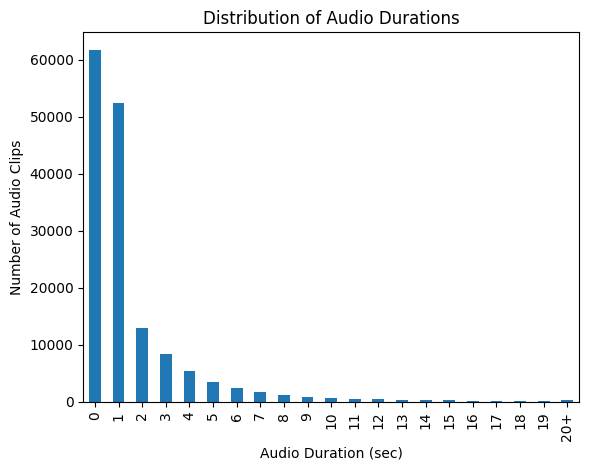

In [8]:
bins = list(range(0, 21)) + [np.inf]
labels = [str(i) for i in range(0, 20)] + ["20+"]

binned = pd.cut(df.audio_duration_sec, bins=bins, labels=labels, right=False)
counts = binned.value_counts().sort_index()

counts.plot(kind="bar")
plt.xlabel("Audio Duration (sec)")
plt.ylabel("Number of Audio Clips")
plt.title("Distribution of Audio Durations")
plt.xticks(rotation=90)
plt.show()

Most audio clips are very short (1-3 seconds). Even though the audio has been clipped to the utterance level, we have some outliers over 20 seconds. Next, let's look at the distribution of utterances by child age.

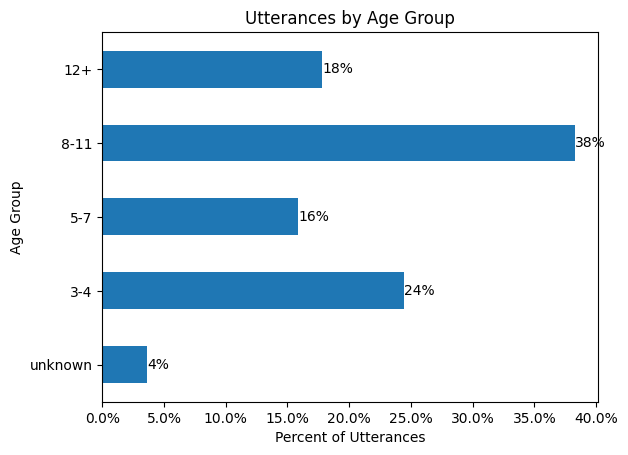

In [9]:
df["age_bucket"] = pd.Categorical(
    df["age_bucket"], categories=["unknown", "3-4", "5-7", "8-11", "12+"], ordered=True
)

fig, ax = plt.subplots()
df["age_bucket"].value_counts(normalize=True, sort=False).plot.barh(ax=ax)
ax.set_title("Utterances by Age Group")
ax.set_xlabel("Percent of Utterances")
ax.set_ylabel("Age Group")
ax.xaxis.set_major_formatter(ticker.PercentFormatter(1.0))
ax.bar_label(ax.containers[0], fmt=lambda x: f"{x * 100:.0f}%")

plt.show()

All age buckets are well represented:
 * 24% of the utterances come from 3 to 4 year olds
 * 16% of the utterances come from 5 to 7 year olds
 * 38% of the utterances come from 8 to 11 year olds
 * 18% of the utterances come from 12 year olds and older

## Let's explore the utterances!

We will listen to an example utterance and explore its phonetic transcription.

<audio controls src="../data-demo/phonetic/audio/U_1c8757065e355c35.flac">

Children’s speech often includes subtle pronunciation differences when compared to adult speech. In the Phonetic Track, models must learn to map pronunciations that vary by age, development, and region to target labels that reflect the phones each child actually produced.

In [10]:
df[df.utterance_id == "U_1c8757065e355c35"][
    ["utterance_id", "audio_duration_sec", "phonetic_text"]
]

,utterance_id,audio_duration_sec,phonetic_text
27819,U_1c8757065e355c35,0.516,jæ


The ground truth `phonetic_text` labels are normalized phonetic transcriptions of individual utterances using the [International Phonetic Alphabet (IPA)](https://en.wikipedia.org/wiki/International_Phonetic_Alphabet), with a one-to-one mapping between Unicode characters and phones. Each transcription captures the full sequence of speech sounds in the corresponding audio clip and may include substitutions, omissions, or non-standard productions that are typically ignored in word-level ASR.

All phonetic labels are restricted to the predefined IPA character set used during phonetic transcription. This set is provided in the [scoring script](https://github.com/drivendataorg/childrens-speech-recognition-runtime/blob/main/metric/score.py) in the runtime repository for local validation of predictions.

___

# Step 2: Build the Model

A straightforward modeling option is to start from a strong pretrained ASR model, then fine-tune on our labeled phonetic child-speech training set. In this tutorial, we fine-tune Facebook's pretrained Wav2Vec2-base model using Hugging Face Transformers. 

Wav2Vec2 is relatively simple and efficient to fine-tune, making it a reasonable starting point for this challenge. It uses a [convolutional neural network](https://en.wikipedia.org/wiki/Convolutional_neural_network) ("CNN") feature extractor followed by a transformer encoder to learn audio representations. 

* A CNN is a neural network that learns useful features from data by applying small pattern detectors called filters. These filters scan across the input (such as an image or audio signal) and learn to recognize important patterns.
* Wav2Vec2 is pretrained on unlabeled speech audio and later fine-tuned for ASR using a defined output vocabulary, typically consisting of characters. For this challenge, we instead define a vocabulary of IPA phone symbols, mapping each phonetic symbol to a unique integer ID.

**We will freeze the feature extractor to preserve the robust pre-trained audio processing capabilities, then fine-tune the transformer encoder and a newly initialized CTC head configured for our phonetic character vocabulary.** Hugging Face makes this process easier by providing model architectures, data processing utilities (tokenizers, feature extractors, data collators), and integrated training pipelines.

Key packages include: 
 * `transformers` for Wav2Vec2 model + training utilities
 * `datasets` for data loading and preprocessing
 * `torch` for the training backend

## 1. Prepare Dataset

We need to process our dataframe containing the DrivenData and TalkBank datasets. We filter out clips longer than 25 seconds, which strain computer memory. Competitors may want to further split these clips to avoid losing training data. We remove one corrupted file before limiting the data to just the phonetic transcription and the audio filepath.

In [11]:
# Filter down to audio less than 25 seconds to reduce strain on memory
df = df[(df.audio_duration_sec <= 25)]

# Filter out corrupted file
df = df[df.utterance_id != "U_b8a4e8220e65219b"]

# For now, we only need the transcript and the audio path
df = df[["phonetic_text", "audio_path"]]

We then create a Hugging Face Dataset from our dataframe, which gives us a standard format that works cleanly with dataset transforms and the training pipeline. We also cast the audio column to 16 kHz so clips are decoded and resampled to the sampling rate expected by Wav2Vec2.

In [12]:
# Audio sampling rate
SR = 16000

# Enforce string types so that datasets can consume them properly
schema = Features(
    {
        "phonetic_text": Value("string"),
        "audio_path": Value("string"),
    }
)

dataset = Dataset.from_pandas(df.reset_index(drop=True), features=schema)
dataset = dataset.cast_column("audio_path", Audio(sampling_rate=SR))

## 2. Build Vocabulary and Tokenizer

Our model treats each IPA character as one token, so it is important that every valid character has a consistent ID. To create a character to ID mapping, we take the imported `VALID_IPA_CHARS` from the scoring script and map each IPA character to an index for the tokenizer.

Special tokens are added to the set of IPA characters: 
 * `|` replaces spaces as the word delimiter
 * `[UNK]` is a fallback token that maps any character not in VALID_IPA_CHARS to a single token ID
 * `[PAD]` is the padding token used to pad sequences to equal length in batches

This mapping is saved so we can reuse the same token IDs when we initialize the tokenizer now and when we load the model for inference later.

In [13]:
# VALID_IPA_CHARS contains the following IPA characters:
print(*VALID_IPA_CHARS)

æ o b c ɑ   ʔ ɛ s j ɹ f ʊ ə ʁ i ɔ v ɟ x ʌ ŋ χ d h ʝ k n l ɐ ʤ ɪ ɚ ç z ː m t ɫ ʃ ʧ w r p ɾ ɬ ʒ θ u g ð e


In [14]:
unk_tok = "[UNK]"
pad_tok = "[PAD]"
space_tok = "|"

all_toks = sorted([char for char in VALID_IPA_CHARS if char != " "]) + [
    unk_tok,
    pad_tok,
    space_tok,
]

vocab_dict = {char: idx for idx, char in enumerate(all_toks)}

vocab_path = DATA_ROOT / "vocab/phonetic_vocab.json"
vocab_path.parent.mkdir(parents=True, exist_ok=True)
with vocab_path.open("w") as f:
    json.dump(vocab_dict, f)

Next, we initialize a tokenizer to convert text labels to token IDs. The tokenizer reads the vocabulary mapping we just saved, so each IPA character and special token uses the same ID during training and inference. We also initialize the feature extractor, which converts raw 16 kHz waveforms into model-ready input values for Wav2Vec2.

Finally, the `Wav2Vec2Processor` is initialized. The processor combines the feature extractor and tokenizer in one object, so we can consistently preprocess audio and encode/decode labels.

In [15]:
tokenizer = Wav2Vec2CTCTokenizer(
    str(vocab_path), unk_token=unk_tok, pad_token=pad_tok, word_delimiter_token=space_tok
)

# Create Wav2Vec2 Feature Extractor
feature_extractor = Wav2Vec2FeatureExtractor(
    feature_size=1,
    sampling_rate=SR,
    padding_value=0.0,
    do_normalize=True,
    return_attention_mask=False,
)

# Create processor (combines tokenizer and feature extractor)
processor = Wav2Vec2Processor(feature_extractor=feature_extractor, tokenizer=tokenizer)

## 3. Create Data Collator

Data collators prepare training batches from variable-length sequences. In our model, since audio clips have different lengths, the data collator adds padding to shorter clips so all clips in a batch have the same length. It marks padded positions in the labels with -100, which tells the training algorithm to ignore those positions when calculating loss.

In [16]:
@dataclass
class DataCollatorCTCWithPadding:
    """
    Data collator that will dynamically pad the inputs received.
    """

    processor: Wav2Vec2Processor
    padding: Union[bool, str] = True
    max_length: Optional[int] = None
    max_length_labels: Optional[int] = None
    pad_to_multiple_of: Optional[int] = None
    pad_to_multiple_of_labels: Optional[int] = None

    def __call__(
        self, features: List[Dict[str, Union[List[int], torch.Tensor]]]
    ) -> Dict[str, torch.Tensor]:
        input_features = [{"input_values": feature["input_values"]} for feature in features]
        label_features = [{"input_ids": feature["labels"]} for feature in features]

        batch = self.processor.pad(
            input_features,
            padding=self.padding,
            max_length=self.max_length,
            pad_to_multiple_of=self.pad_to_multiple_of,
            return_tensors="pt",
        )
        labels_batch = self.processor.tokenizer.pad(
            label_features,
            padding=self.padding,
            max_length=self.max_length_labels,
            pad_to_multiple_of=self.pad_to_multiple_of_labels,
            return_tensors="pt",
        )

        # replace padding with -100 to ignore loss correctly
        labels = labels_batch["input_ids"].masked_fill(labels_batch.attention_mask.ne(1), -100)

        batch["labels"] = labels

        return batch


# Initialize data collator
data_collator = DataCollatorCTCWithPadding(processor=processor, padding=True)

## 4. Preprocess Audio

We define a preprocessing function that extracts features and tokenizes the phonetic text labels using the `Wav2Vec2Processor` object we already created. The function replaces spaces with word delimiters before tokenization to prepare labels for training.

In [17]:
def preprocess_batch(examples):
    # Start by loading the audio and processing with the feature extractor
    processed_batch = {
        "input_values": [
            processor(item["array"], sampling_rate=SR).input_values[0]
            for item in examples["audio_path"]
        ]
    }

    # Replace spaces with word delimiter and tokenize for CTC
    processed_batch["labels"] = [
        processor(text=ex.replace(" ", "|")).input_ids for ex in examples["phonetic_text"]
    ]

    return processed_batch

We apply this preprocessing across the dataset in parallel and save the results to disk for faster development iteration.

In [18]:
PROCESSED_DATASET_DIR = DATA_ROOT / "processed" / "phonetic_dataset"

if PROCESSED_DATASET_DIR.exists():
    processed_dataset = load_from_disk(str(PROCESSED_DATASET_DIR))
    print(
        f"Loaded preprocessed dataset from {PROCESSED_DATASET_DIR.relative_to(PROJECT_ROOT)} ({len(processed_dataset)} examples)"
    )
else:
    processed_dataset = dataset.map(preprocess_batch, batched=True, num_proc=4)
    processed_dataset.save_to_disk(str(PROCESSED_DATASET_DIR))
    print(f"Preprocessed and saved dataset to {PROCESSED_DATASET_DIR.relative_to(PROJECT_ROOT)}")

Map (num_proc=4):   0%|          | 0/152997 [00:00<?, ? examples/s]

Saving the dataset (0/78 shards):   0%|          | 0/152997 [00:00<?, ? examples/s]

Preprocessed and saved dataset to data/processed/phonetic_dataset


## 5. Model Configuration and Training Setup

We load the pretrained Wav2Vec2-base model with a CTC architecture and initialize a new CTC head configured for our phonetic vocabulary. CTC enables direct audio-to-phone prediction without requiring explicit alignment between audio frames and individual characters. This simplifies our setup because we don't have to label exactly when each phone occurs in the audio, rather we just have to specify the sequence of phones.

The feature extractor is frozen to preserve audio processing learned from the model pretraining; we lock those weights and don't update them during training. We will only fine-tune the transformer encoder (which learns acoustic patterns) and the CTC head (which converts these patterns into phone predictions).

In [19]:
# Load pretrained Wav2Vec2 model
model = Wav2Vec2ForCTC.from_pretrained(
    "facebook/wav2vec2-base",
    ctc_loss_reduction="mean",
    ctc_zero_infinity=True,  # Replace inf CTC loss with 0 to prevent NaN gradients
    pad_token_id=processor.tokenizer.pad_token_id,
    ignore_mismatched_sizes=True,
    vocab_size=len(processor.tokenizer),
)

# Freeze feature extractor layers
model.freeze_feature_encoder()

/.venv/lib/python3.11/site-packages/transformers/configuration_utils.py:309: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['lm_head.bias', 'lm_head.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


We then filter out a few utterances that violate CTC's length constraints. This violation occurred because, for some utterances, there were too many tokens for the audio time. Wav2Vec2 downsamples audio by 320x, so the output sequence length must exceed the label length to avoid infinite loss values.

In [20]:
# Filter out samples that violate the CTC constraint:
# Wav2Vec2 downsamples audio by 320x, so input_length // 320 must be > label_length.
# Samples violating this produce inf CTC loss -> NaN gradients.
WAV2VEC2_DOWNSAMPLE = 320
before_filter = len(processed_dataset)


def is_valid_ctc_sample(example):
    input_len = len(example["input_values"])
    label_len = len(example["labels"])
    # CTC requires: output_timesteps > label_length (including blanks)
    output_timesteps = input_len // WAV2VEC2_DOWNSAMPLE
    return output_timesteps > label_len and label_len > 0 and input_len > 0


processed_dataset = processed_dataset.filter(is_valid_ctc_sample, num_proc=4)
print(
    f"CTC filter: {before_filter} -> {len(processed_dataset)} samples ({before_filter - len(processed_dataset)} removed)"
)

Filter (num_proc=4):   0%|          | 0/152997 [00:00<?, ? examples/s]

CTC filter: 152997 -> 152989 samples (8 removed)


The Trainer expects separate training and validation datasets, so we can simply split our `processed_dataset` such that 90% goes to training and 10% goes to validation.

In [21]:
# Split dataset into train and validation
dataset_split = processed_dataset.train_test_split(test_size=0.1, shuffle=True, seed=42)

train_dataset = dataset_split["train"]
eval_dataset = dataset_split["test"]

While the loss function drives the actual training and weight updates, the final metric upon which model inferences will be evaluated is Character Error Rate ("CER"). CER measures the edit distance between predicted and reference phonetic sequences at the character level. In training, whenever we compute validation loss, we also calculate the CER so that we can monitor training progress on a human-interpretable metric and select the best model checkpoint. 

To compute CER, we run the model on the validation dataset to generate phone predictions, then compare them to the ground truth labels. The `score_ipa_cer` function is taken directly from the [runtime repository](https://github.com/drivendataorg/childrens-speech-recognition-runtime/blob/main/metric/score.py). Please note that the `score_ipa_cer` function normalizes the prediction and reference text before computing the CER.

In [22]:
def compute_metrics(pred):
    """Compute Character Error Rate (CER) for phonetic transcription."""
    pred_logits = pred.predictions
    pred_ids = np.argmax(pred_logits, axis=-1)

    # Replace -100 with pad_token_id for decoding
    pred.label_ids[pred.label_ids == -100] = processor.tokenizer.pad_token_id

    # Decode predictions and labels
    pred_str = processor.batch_decode(pred_ids)
    # Don't group tokens when computing metrics (important for CTC)
    label_str = processor.batch_decode(pred.label_ids, group_tokens=False)

    return {"cer": score_ipa_cer(label_str, pred_str)}

Finally, the training hyperparameters are configured with reasonable starting points, such as: 
* learning rate of 5e-5
* batch size of 27 with gradient accumulation
* 20 epochs with a linear warmup and decay learning rate schedule
* evaluation every 1000 steps

The Hugging Face Trainer handles the training loop, checkpointing, and evaluation.

In [23]:
# Define training arguments
output_dir = str(PROJECT_ROOT / "models" / "wav2vec2-phonetic")

training_args = TrainingArguments(
    output_dir=output_dir,
    group_by_length=False,
    per_device_train_batch_size=27,
    per_device_eval_batch_size=27,
    gradient_accumulation_steps=2,
    max_grad_norm=1.0,
    learning_rate=5e-5,
    num_train_epochs=20,
    weight_decay=0.01,
    eval_strategy="steps",
    eval_steps=1000,
    save_steps=1000,
    logging_steps=100,
    warmup_steps=500,  # Shorter warmup for fewer epochs
    lr_scheduler_type="linear",
    bf16=True,
    fp16=False,
    gradient_checkpointing=False,
    dataloader_num_workers=8,
    dataloader_pin_memory=True,
    save_total_limit=2,
    metric_for_best_model="cer",
    greater_is_better=False,
    load_best_model_at_end=True,
    report_to="none",
)

# Initialize trainer
trainer = Trainer(
    model=model,
    data_collator=data_collator,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=processor,
)

## 6. Train the Model

Let's fine-tune the pre-trained model to predict phones from child speech!

In [24]:
trainer.train()

/.venv/lib/python3.11/site-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)


Step,Training Loss,Validation Loss,Cer
1000,2.737000,2.372736,0.804864
2000,1.511900,1.412020,0.437561
3000,1.329400,1.259690,0.411161
4000,1.217900,1.158037,0.405470
5000,1.177500,1.124078,0.385218
6000,1.097700,1.099532,0.380330
7000,1.069700,1.064977,0.374003
8000,1.022000,1.048235,0.368162
9000,0.995600,1.019231,0.369283
10000,1.001500,1.003653,0.362655


TrainOutput(global_step=51000, training_loss=1.2747246808070762, metrics={'train_runtime': 19869.636, 'train_samples_per_second': 138.593, 'train_steps_per_second': 2.567, 'total_flos': 2.43363172711743e+20, 'train_loss': 1.2747246808070762, 'epoch': 20.0})

## 7. Evaluate and Test Inference

Now it's time to assess how well our final fine-tuned model performs. We evaluate on the validation set to compute the overall CER, then run inference on random samples to inspect individual predictions.

In [25]:
# Evaluate on validation set
eval_results = trainer.evaluate()

print("Evaluation Results:")
print(f"  CER: {eval_results['eval_cer']:.4f}")
print(f"  Loss: {eval_results['eval_loss']:.4f}")

Evaluation Results:
  CER: 0.3289
  Loss: 0.9254


Our model results in a CER of .33 on the validation set.

In [26]:
# Run inference on a few samples

model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Get a few random samples
num_samples = 5
sample_indices = random.sample(range(len(eval_dataset)), num_samples)

print("Sample predictions:")
print("=" * 80)

for idx in sample_indices:
    sample = eval_dataset[idx]

    # Prepare input
    input_values = torch.tensor(sample["input_values"]).unsqueeze(0).to(device)

    # Get prediction
    with torch.no_grad():
        logits = model(input_values).logits

    pred_ids = torch.argmax(logits, dim=-1)

    # Decode
    pred_str = processor.decode(pred_ids[0])
    label_str = processor.decode(sample["labels"], group_tokens=False)

    print(f"\nSample {idx}:")
    print(f"  Ground truth: {label_str}")
    print(f"  Prediction:   {pred_str}")

    # Calculate CER for this sample
    cer = score_ipa_cer([label_str], [pred_str])
    print(f"  CER: {cer:.4f}")

print("\n" + "=" * 80)

Sample predictions:



Sample 10476:
  Ground truth: dei ɑksd dʌ dɑːktɚ tu hæv gɪv sʌm fɑiv sents
  Prediction:   ðei ækst ðə dɑktɚ tu hæv gɪv sʌm fɑiv sɛnts
  CER: 0.1591

Sample 1824:
  Ground truth: nʊs
  Prediction:   nəs
  CER: 0.3333

Sample 409:
  Ground truth: ʧɹɑieŋgɫ
  Prediction:   ʧɹɑieŋgɫ
  CER: 0.0000

Sample 12149:
  Ground truth: ɔw
  Prediction:   ɔə
  CER: 0.5000

Sample 4506:
  Ground truth: ʃʌvɫ
  Prediction:   ʃʌvʊɫ
  CER: 0.2500



Finally, we save the model, processor, and training configuration to disk.

In [27]:
# Save model + processor for reuse on another machine
save_dir = PROJECT_ROOT / "models" / "wav2vec2-phonetic-final"
save_dir.mkdir(parents=True, exist_ok=True)

# Trainer saves model + config + tokenizer config if provided
trainer.save_model(str(save_dir))

# Save processor artifacts (tokenizer + feature extractor)
processor.save_pretrained(str(save_dir))

processor.feature_extractor.save_pretrained(str(save_dir))

torch.save(training_args, save_dir / "training_args.pt")

___
# Step 3: Make your submission

Since this is a code execution competition, we will submit our model weights and inference code rather than predictions. The platform runs your `main.py` in a container, which must load your model and output the file `submission/submission.jsonl`. See the [code submission format](https://www.drivendata.org/competitions/309/childrens-phonetic-asr/page/981/) webpage for more information.

The general steps to follow:

1. Develop inference code
2. Test your submission locally
3. Package submission
4. Make a smoke test submission
5. Once you have successfully debugged your submission, submit it for scoring on the full test set!


## Develop Inference Code

We need to set up a repository with a `main.py` Python script which performs inference in the [competition execution environment](https://github.com/drivendataorg/childrens-speech-recognition-runtime/tree/main) and writes our predictions to the required output file.  During code execution, our submission will be unzipped and run in the cloud compute cluster. The container will run your `main.py` script.

Our code must write a JSON Lines (JSONL) file containing one prediction per utterance.

Each line must include:
- `utterance_id`
- `phonetic_text`: UTF-8, International Phonetic Alphabet (IPA) transcription of the utterance.

The submission should be written to `./submission/submission.jsonl` relative to the working directory.

See more details in the [code submission format](https://www.drivendata.org/competitions/309/childrens-phonetic-asr/page/981/) webpage and in the [example submission](https://github.com/drivendataorg/childrens-speech-recognition-runtime/tree/main/examples/phonetic/parakeet-cmudict).

In our `main.py`, we load the fine-tuned Wav2Vec2 model and processor from the saved checkpoint directory, then run inference on all test utterances in batches. The script reads audio file paths from the test manifest, processes the audio through the model, decodes the model outputs to phonetic predictions, and writes the predicted phonetic transcriptions to the submission file in the required format. We batch utterances to improve GPU memory efficiency during processing.

See [`phonetic_submission/main.py`](../phonetic_submission/main.py) for the details.

## Test Submission Locally

You should first and foremost test your submission locally. This is a great way to work out any bugs and ensure that your model performs inference successfully. See the [runtime repository's README](https://github.com/drivendataorg/childrens-speech-recognition-runtime/tree/main?tab=readme-ov-file#testing-a-submission-locally) for further instructions.

This repository provides a useful [justfile](../justfile) command to run the trained model on a few sample files.

```bash
test-phonetic:
    uv run phonetic_submission/main.py models/wav2vec2-phonetic-final/ data-demo/phonetic/utterance_metadata.jsonl
```

## Package Submission

Now we will package up our model and inference code into a zip file for predicting on the test set in the runtime container. This repository provides a [justfile](../justfile) command to do this. The command creates a zip file combining the trained Wav2Vec2 model with `/phonetic_submission/main.py`.

```bash
pack-phonetic:
    rm -f phonetic_submission.zip && \
    (cd phonetic_submission && zip -r ../phonetic_submission.zip main.py) && \
    (cd models && zip -r ../phonetic_submission.zip wav2vec2-phonetic-final/)
```

## Make a Smoke Test Submission

We provide a "smoke test" environment that replicates the test inference runtime but runs only on a small set of audio files. In the smoke test runtime, data/ contains 3,000 audio files from the training set. 

Let's submit our submission.zip to a smoke test on the platform.

![Smoke Test Submission](images/smoke_test_phonetic.png)

After hitting "Submit" you can see the job in the queue—it will progress from "Uploading" to "Pending" to "Starting" to "Running" to "Scoring":

![Smoke Test Code Jobs](images/smoke_test_jobs_phonetic.png)

Once your submission reaches "Completed", head on over to the "Submissions" tab to see your smoke test score.

## Submit!

After you've made sure a smoke test submission runs without error, you're ready to submit the real deal! This fine-tuned Wav2Vec2 model results in a .3460 CER on the full test set.

![Full Submission](images/submission_phonetic.png)

We encourage you to also be mindful of the submission limit (3 per 7 days at most) and others' code jobs. Canceled jobs do not count against the submission limit.

If you want to share any of your findings or have questions, feel free to post on the [community forum](https://community.drivendata.org/c/childrens-asr/109). 

Good luck!